In [31]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer


In [4]:
df=pd.read_csv('concrete_data.csv')

In [5]:
df.head(4)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05


In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
X=df.drop(columns=['Strength'])

In [10]:
Y=df['Strength']

In [12]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    Y,
    test_size=0.2
    ,random_state=42
)

In [24]:
lr=LinearRegression()

In [25]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred=lr.predict(X_test)

In [28]:
r2_score(y_test,y_pred)

0.6275531792314852

In [29]:
lr=LinearRegression()
np.mean(cross_val_score(lr,X,Y,scoring='r2'))

np.float64(0.4609940491662864)

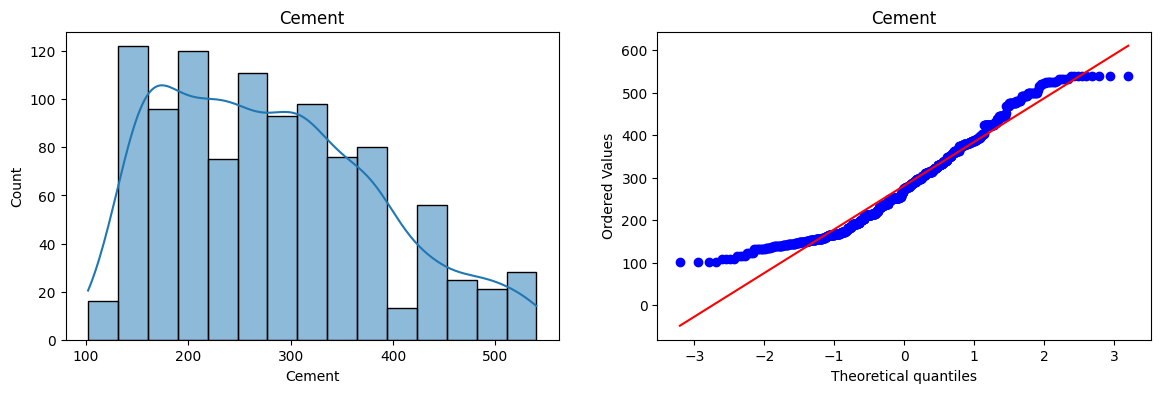

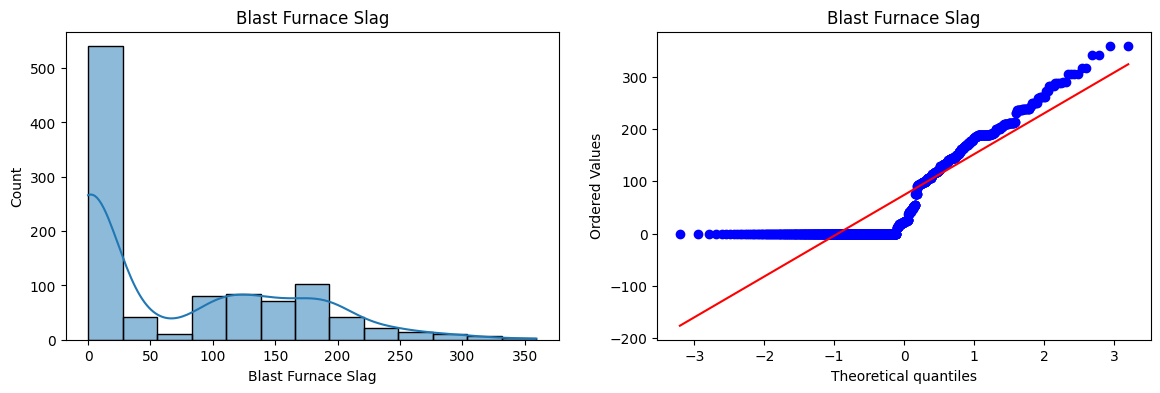

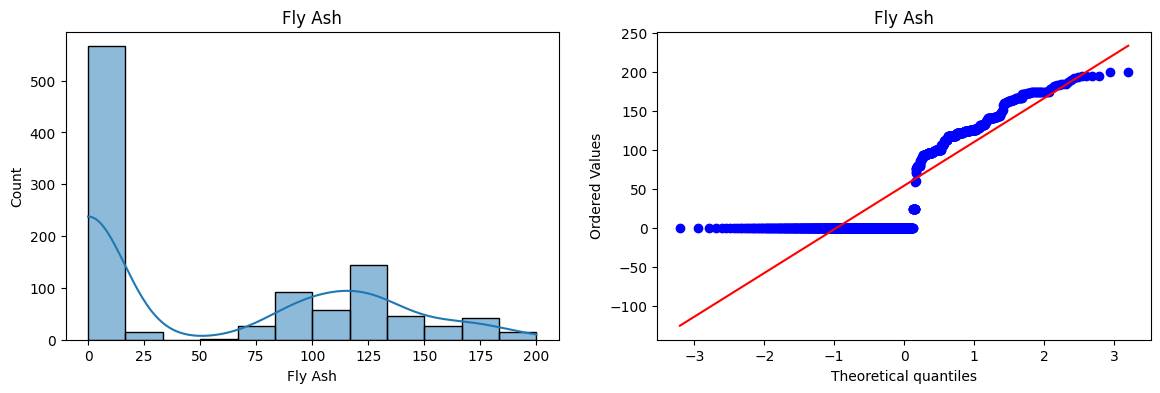

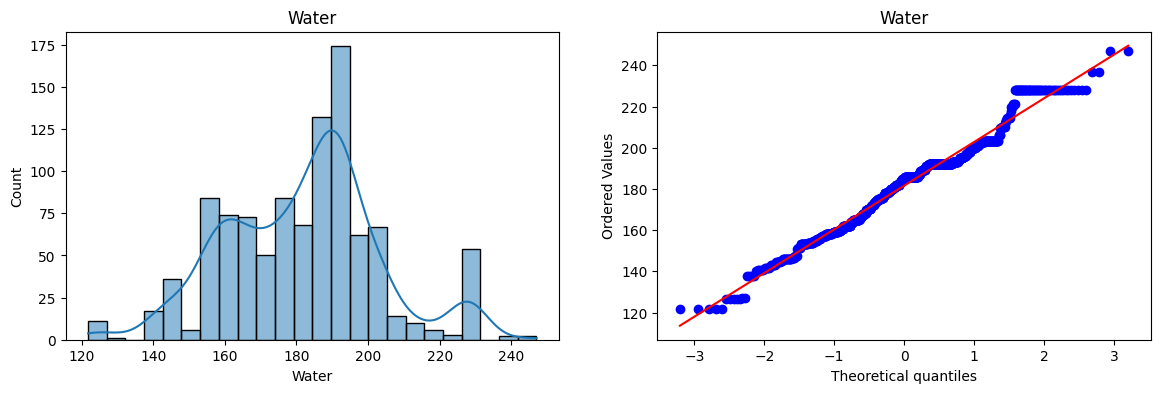

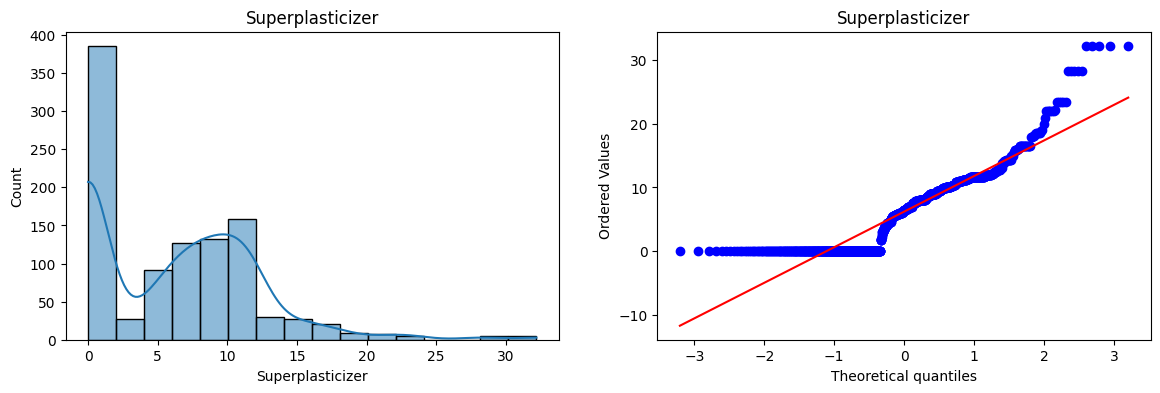

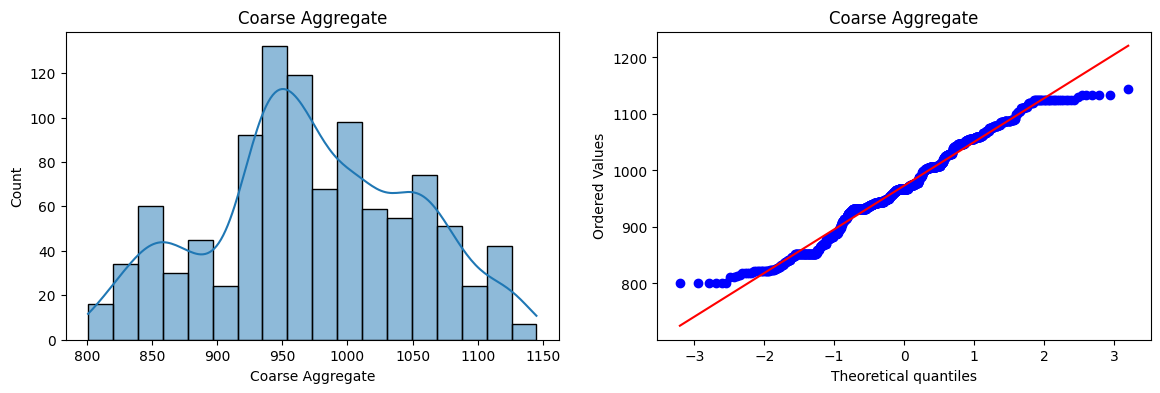

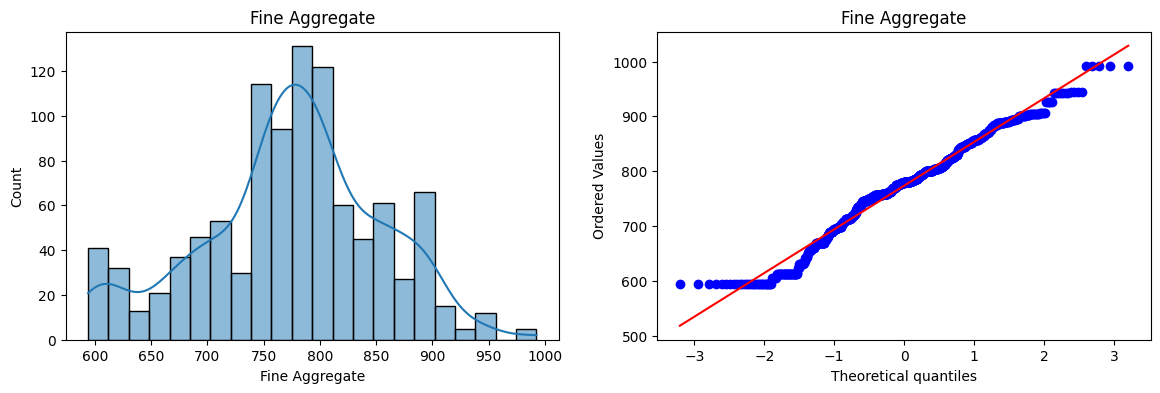

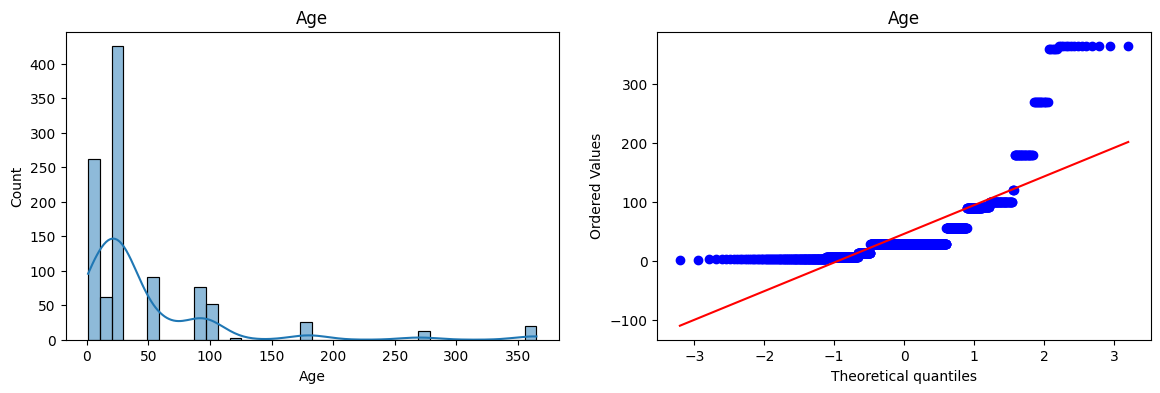

In [38]:
for col in X.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X[col],dist='norm',plot=plt)
    plt.title(col)

    plt.show()

In [46]:
# Applying BOX COX
pt=PowerTransformer(method='box-cox')
X_train_transformed=pt.fit_transform(X_train+0.00000001)
X_test_transformed=pt.transform(X_test+0.00000001)
pd.DataFrame({'cols':X_train.columns,'box-cox-lamba':pt.lambdas_})

,cols,box-cox-lamba
0,Cement,0.177025
1,Blast Furnace Slag,0.020795
2,Fly Ash,-0.031170
3,Water,0.772682
4,Superplasticizer,0.077874
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [47]:
## applying Linear Regression
lr=LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred=lr.predict(X_test_transformed)
r2_score(y_test,y_pred)

0.8038298017767421

In [48]:
pt=PowerTransformer(method='box-cox');
X_transformed=pt.fit_transform(X+0.000000001)
lr=LinearRegression()

np.mean(cross_val_score(lr,X_transformed,Y,scoring='r2'))

np.float64(0.6651894385855058)

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


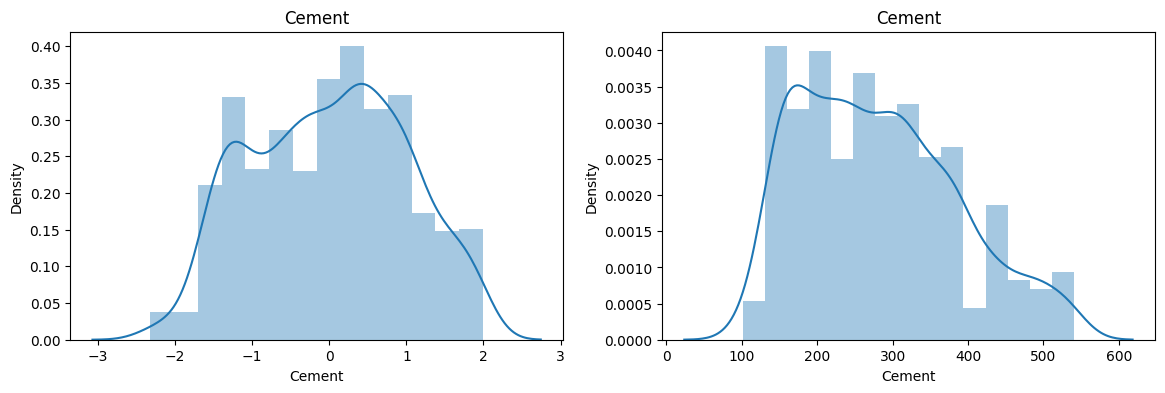

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


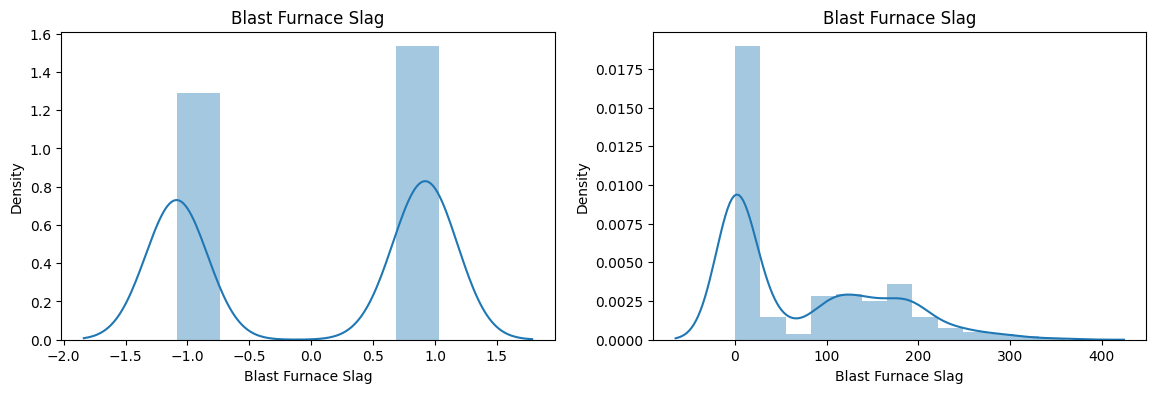

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


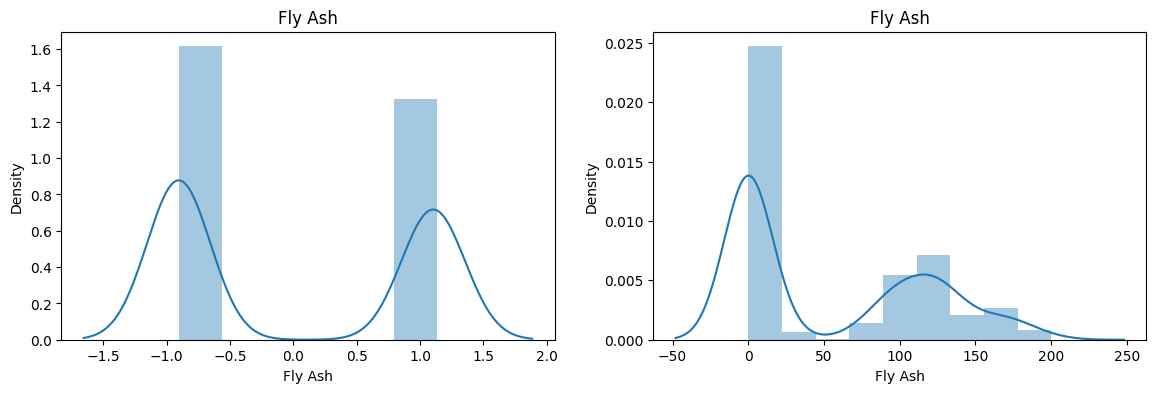

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


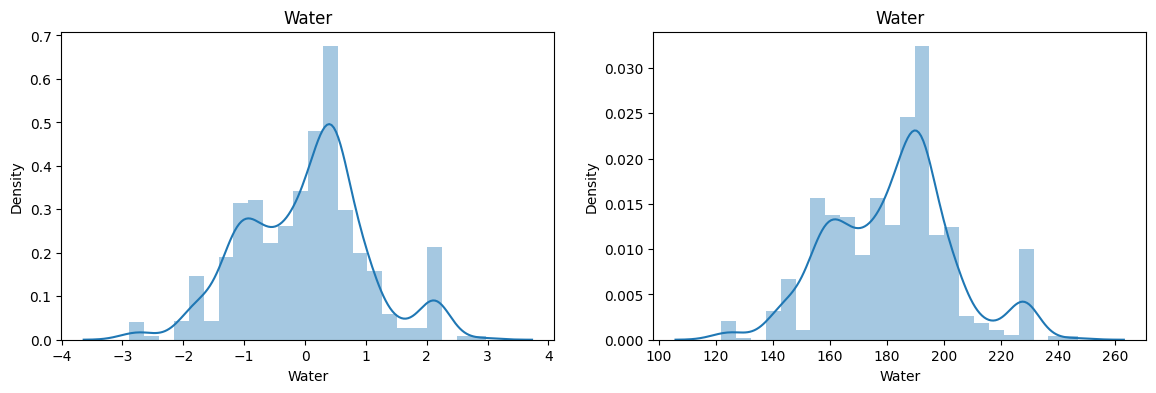

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


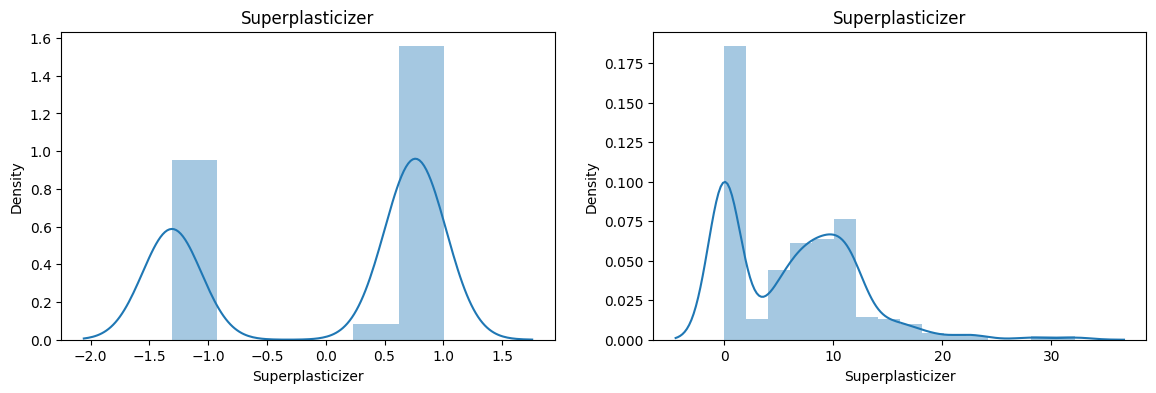

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


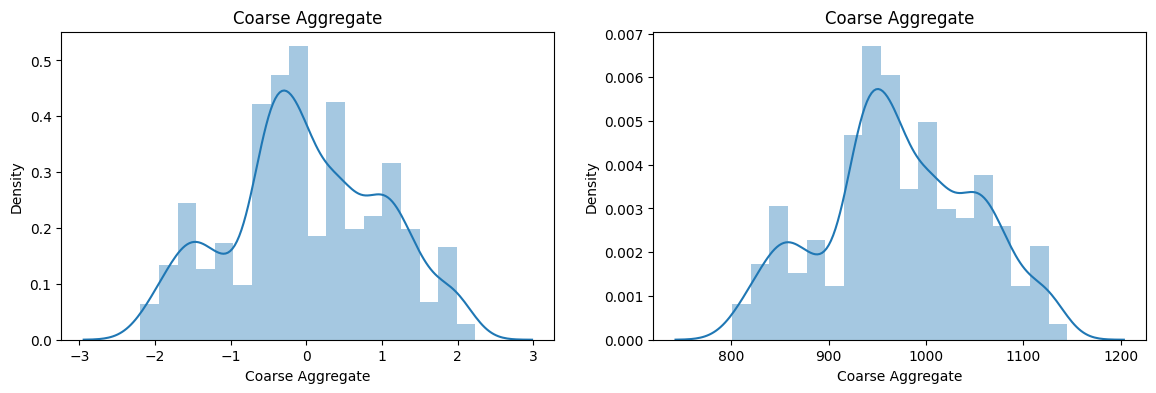

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


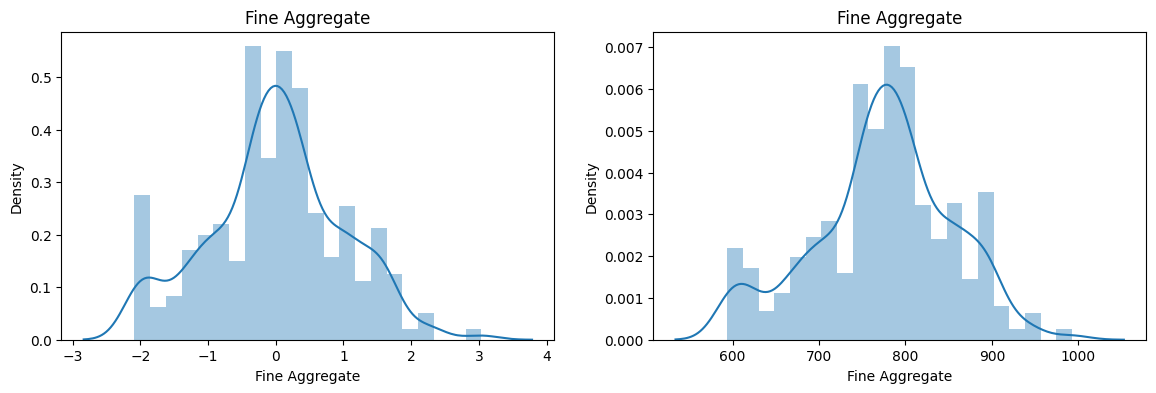

C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_2[col],kde=True)
C:\Users\mazda computer\AppData\Local\Temp\ipykernel_3336\3749926320.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],kde=True)


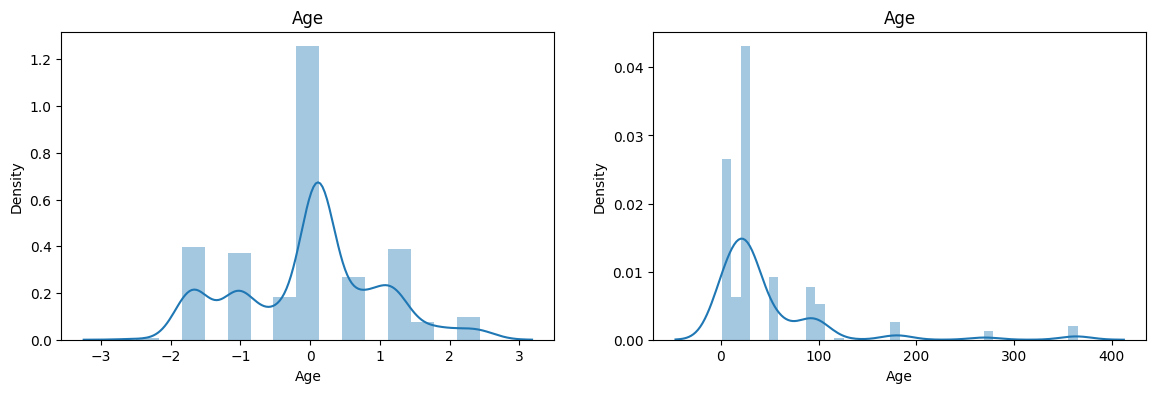

In [58]:
X_2=pd.DataFrame(X_transformed,columns=X.columns)
for col in X.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_2[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.distplot(X[col],kde=True)
    plt.title(col)

    plt.show()